If you want this to be *substantial*, the trick is to stop treating it like “NLP on political text” and start treating it like **a reproducible measurement framework for rhetoric**. Then the “new insights” are: what you can quantify, how stable it is, and what changes across years.

Your three transcripts are a clean corpus (same genre, same setting, different era): Obama 2012 ([millercenter.org][1]), Trump 2020 ([millercenter.org][2]), Biden 2024 ([millercenter.org][3]).

## A story that sounds like insight (and is)

### Thesis

**LLMs are not just for summarizing speeches. They let you instrument speeches.**
You can quantify: agenda structure, framing, coalition targeting, and rhetorical “moves,” then compare across years.

### The punchier version

* Word clouds show **frequency**.
* Transformers let you measure **salience, structure, and framing**.

## The 5 analysis lenses that make a real “speech analytics” narrative

### 1) Agenda structure: what buckets exist and how the speech allocates time

Deliverable:

* Chunk speech into fixed units (say 3–5 sentences).
* Embed each chunk.
* Cluster chunks into topics (k ~ 8–12).
* Output: topic labels + % of speech per topic + a timeline strip showing topic order.

Insight you can credibly claim:

* SOTUs have a predictable scaffold, but **the allocation and sequencing** differ, and the differences are measurable.

Why it’s good:

* It’s visual and robust. It still works if the model is small.

### 2) Rhetorical moves: “what is the speaker doing right now?”

Instead of topics, label each chunk as a *move*, like:

* accomplishment/scoreboard
* threat/urgency
* values/identity
* policy proposal
* bipartisanship appeal
* contrast/adversary framing
* anecdote/human story
* call to action

How:

* Use an open-source LLM to classify each chunk into one move (or multi-label).
* Then compare move distributions across years.

Insight:

* You can show, for example, one speech spending more time on “scoreboard + contrast,” another on “threat + values + call to action,” etc., without doing punditry.

### 3) Framing ratios: policy vs values vs conflict

A simple, high-signal metric set:

* **Policy density**: how often we see concrete proposals, numbers, legislation names.
* **Values density**: words/phrases tied to freedom, democracy, fairness, dignity, etc.
* **Conflict density**: explicit “they/our opponents,” blame, attack, “the other side,” “predecessor,” etc.

Why it’s real:

* This is the “instrumentation” angle. You’re quantifying how a speech persuades, not just what it says.

You already see distinct openings in 2020 and 2024 that are basically “scoreboard” vs “urgent threat framing” right out of the gate. ([Miller Center][2])

### 4) Coalition targeting: “who is being addressed?”

Extract and categorize mentions of:

* workers, families, seniors
* small business
* military/veterans
* women
* immigrants/border/security
* students/education
* rural/farmers/manufacturing
* allies/adversaries

How:

* NER + noun phrase extraction + a lightweight classifier (or rules).
* Output: a “who is the audience” scoreboard by year.

Insight:

* Reelection-year speeches are coalition maintenance. This lets you show it with data.

### 5) Entity + policy network: what concepts are linked together

Deliverable:

* Build a graph where nodes are entities/policies and edges are co-occurrence within a sentence/window.
* Community detection reveals “issue constellations.”

Insight:

* This is where you get non-obvious findings like: “In 2024, democracy framing is tightly linked to foreign policy references early,” which is visible in the transcript opening. ([Miller Center][3])

## “New insights” you can safely aim for (without guessing results)

These are phrased as research questions you can answer with the pipeline:

1. **How stable is the SOTU template?**
   Do all three show similar topic ordering (foreign policy opener, economic core, domestic policy laundry list, closing values), or does one break the mold?

2. **Which speech is more “proposal-heavy” vs “frame-heavy”?**
   Quantify policy density and values density per 1,000 words.

3. **Is the “adversary” mostly external or internal?**
   2024 explicitly frames threats at home and abroad in the opening. ([Miller Center][3])
   2020’s early framing is accomplishment + national resurgence language. ([Miller Center][2])
   Obama 2012 opens with military accomplishments and then moves into “economy built to last.” ([Miller Center][1])

4. **Do rhetorical moves cluster by era?**
   2012: blueprint language, “built to last” economic narrative appears early. ([Miller Center][1])
   2020: “great American comeback” scoreboard framing is explicit. ([Miller Center][2])
   2024: democracy under assault framing is explicit. ([Miller Center][3])

That’s not punditry. That’s the speeches telling you what they’re doing.

## What makes this “LLM-powered” and not “statistics in a trench coat”

Be explicit in the write-up:

* **Embeddings** give you semantic grouping (topics, structure).
* **LLM classification** gives you rhetorical move labeling at scale.
* Optional: attention-based salience as a “lens,” but don’t hang the paper on attention. It’s a demo tool more than an evidence tool.

## A clean “mini paper” outline you can publish (blog/LinkedIn)

1. Problem: Comparing speeches is usually vibes.
2. Data: 2012, 2020, 2024 SOTU transcripts (Miller Center).
3. Method: chunking, embeddings + clustering, move labeling, density metrics, entity graph.
4. Findings: 3–6 charts with short interpretations.
5. Limitations: model bias, transcript formatting, classification uncertainty, sensitivity to chunk size/k.
6. Repro: a single notebook + config file + pinned model versions.

## If you want one chart that wins hearts immediately

Do the **timeline strip**: x-axis = chunk index; color = topic cluster; annotate 5–8 topic labels. It makes “structure” visible in 2 seconds.

---

If you want, I can give you a tight “analysis spec” (inputs/outputs, parameter defaults, and exactly which models to use locally) so you can run it once and write about the results without fiddling live.

[1]: https://millercenter.org/the-presidency/presidential-speeches/january-24-2012-2012-state-union-address "January 24, 2012: 2012 State of the Union Address | Miller Center"
[2]: https://millercenter.org/the-presidency/presidential-speeches/february-4-2020-state-union-address "February 4, 2020: State of the Union Address | Miller Center"
[3]: https://millercenter.org/the-presidency/presidential-speeches/march-7-2024-state-union-address "March 7, 2024: State of Union Address | Miller Center"


Yes. The spec is your guardrails. It forces you to decide what you will measure, how you will measure it, and what artifacts you will produce, before you get distracted by shiny model knobs.

Here is a practical analysis spec you can use as the backbone for a substantial demo and a write-up.

## Speech Analytics Spec v1

### 0) Goal

Compare 2012, 2020, 2024 SOTU speeches on:

* agenda structure (topics over time)
* rhetorical moves (what the speaker is doing)
* framing densities (policy vs values vs conflict)
* coalition targeting (who is addressed)
* entity-policy networks (what concepts are linked)

### 1) Data

Source transcripts (canonical):

* 2012 SOTU (Miller Center)
* 2020 SOTU (Miller Center)
* 2024 SOTU (Miller Center)

Ingestion rules:

* Strip navigation, headers, footers.
* Keep only transcript body.
* Normalize whitespace.
* Preserve paragraph boundaries if possible.

Output artifacts:

* `data/raw/{year}.txt`
* `data/clean/{year}.json` with fields:

  * `year`
  * `source_url`
  * `paragraphs[]` (cleaned strings)

### 2) Chunking

Purpose: create comparable units for embedding and labeling.

Rules:

* Split into sentences.
* Group into chunks of 3 sentences (default).
* Overlap: 1 sentence overlap (default) to smooth boundaries.

Parameters:

* `chunk_sentences = 3`
* `chunk_overlap = 1`
* `max_tokens_per_chunk = 180` (truncate or re-chunk if needed)

Output:

* `chunks/{year}.jsonl` with:

  * `chunk_id`
  * `year`
  * `chunk_index`
  * `text`
  * `char_start`, `char_end` (optional)

### 3) Topic structure (embeddings + clustering)

Model:

* Sentence embeddings: `sentence-transformers/all-MiniLM-L6-v2` (fast, solid)

Method:

* Embed each chunk.
* Cluster within each speech OR across all speeches (choose one; default is across all to keep topic IDs consistent).
* Clustering algorithm: `MiniBatchKMeans`

Defaults:

* `k_topics = 10`
* `cluster_scope = "global"` (all years together)
* `random_state = 0`

Topic labeling:

* For each topic cluster, extract top n-grams (1–2 grams) by count within that cluster.
* Optionally use KeyBERT-style centroid similarity for nicer labels.

Outputs:

* `topics/global_topics.json`:

  * `topic_id -> label_terms[]`
* `topics/chunk_topics.jsonl`:

  * `chunk_id -> topic_id`

Primary visuals:

* Topic timeline strip per speech (chunk index vs topic color)
* Topic share bar chart per speech (% chunks per topic)

### 4) Rhetorical move labeling

Goal: classify each chunk into one rhetorical move.

Moves (fixed label set):

1. Accomplishment/scoreboard
2. Problem/threat/urgency
3. Values/identity
4. Policy proposal
5. Bipartisanship/invitation
6. Contrast/adversary framing
7. Anecdote/human story
8. Call to action / closing

Method options:
A) Local LLM classifier (preferred if you want “LLM-powered”)

* Use a small instruction model you can run locally (examples: Llama 3.1 8B Instruct, Qwen2.5 7B Instruct) via Transformers or Ollama.
* Prompt: single-label classification with a short rationale.
* Use temperature 0 for stability.

B) Non-LLM baseline (backup)

* Use a linear classifier on embeddings with a small hand-labeled set (30–60 chunks). This is more work up front, more defensible long term.

Outputs:

* `moves/chunk_moves.jsonl`:

  * `chunk_id -> move_label`
  * optional `rationale` (keep short)

Visuals:

* Move timeline strip per speech
* Move distribution per year

Reliability check:

* Label 30 random chunks twice (same model, same prompt) and confirm stability at temp=0.
* Optionally have a human label 20 chunks and compute agreement.

### 5) Framing densities

Compute per speech and per chunk:

* Policy density: presence of numbers, bill names, program names, “will/plan/act,” etc.
* Values density: curated lexicon (freedom, democracy, dignity, justice, rights, etc.)
* Conflict density: “they/them,” blame verbs, opponent references, “predecessor,” “extremists,” etc.

This is mostly rules + lexicons. Keep it transparent.

Outputs:

* `metrics/chunk_densities.jsonl`
* `metrics/speech_summary.json`

Visuals:

* Line plot of densities across chunk index
* Summary table per year (per 1k words)

### 6) Coalition targeting

Extract mentions of audience groups:

* workers, families, seniors, veterans, small business, women, students, immigrants, etc.

Method:

* Noun phrase extraction + dictionary mapping (simple and robust)
* Optionally refine with an LLM: “Does this sentence target any of these groups?”

Outputs:

* `coalition/mentions.jsonl` with normalized categories
* per-speech counts and rates

Visual:

* Radar chart or grouped bars per year

### 7) Entity-policy network

Entities:

* NER (spaCy) for PERSON/ORG/GPE plus key noun phrases.

Edges:

* Co-occurrence within a sentence or within a 2-sentence window.
* Weight edges by frequency.

Outputs:

* `graph/{year}_nodes.csv`, `graph/{year}_edges.csv`

Visual:

* Network plot (or export to Gephi)

### 8) Deliverables checklist (what you ship)

Minimum viable “substantial” package:

* One notebook that runs end-to-end
* 5 figures:

  1. topic timeline (x3 speeches)
  2. topic share comparison
  3. move distribution comparison
  4. density lines comparison
  5. coalition targeting comparison
* A short write-up: “method, findings, limitations”

### 9) Guardrails (so you do not oversell)

* Do not claim “intent” or “truth,” only measured patterns.
* Report sensitivity: show results with k=8 and k=12 and confirm the main story survives.
* Keep model versions pinned.

---

How you use this in practice:

* You build the demo by implementing the spec top to bottom.
* Each section produces a tangible artifact.
* If something breaks, you know exactly which stage failed.

If you want, I can turn this into a repo skeleton (folders + config YAML + notebook outline) and a short “demo talk track” that explains each chart in one sentence.


In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np

BASE = Path("/Users/douglasdaly/Documents/GitHub/Generative-AI/assets/sotu-speech-analytics")

PATH_TOPICS = BASE / "data/derived/topics_global/global_chunk_topics.jsonl"
PATH_TOPIC_LABELS = BASE / "data/derived/topics_global/global_topic_labels_llm.json"
PATH_RHET = BASE / "data/derived/rhetoric/global_chunk_rhetoric.jsonl"

def read_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

topics = pd.DataFrame(read_jsonl(PATH_TOPICS))
rhet = pd.DataFrame(read_jsonl(PATH_RHET))


# Treat empty strings as NaN
rhet["error"] = rhet["error"].replace("", np.nan)

# Define "good" rows
rhet["is_good"] = rhet["tone"].notna() & rhet["device"].notna() & rhet["target"].notna() & rhet["error"].isna()

# Confidence ranking
conf_rank = {"low": 0, "med": 1, "high": 2}
rhet["conf_rank"] = rhet["confidence"].map(conf_rank).fillna(-1)

# Sort so best rows come first, then drop duplicates on chunk_id
rhet_sorted = rhet.sort_values(
    by=["is_good", "conf_rank"],
    ascending=[False, False],
)

rhet_dedup = rhet_sorted.drop_duplicates(subset=["chunk_id"], keep="first").drop(columns=["is_good", "conf_rank"])

# Now merge using the deduped rhetoric
df = topics.merge(
    rhet_dedup,
    on=["chunk_id"],  # chunk_id is unique; year/index/topic are already in topics
    how="left",
    suffixes=("", "_r")
)



In [2]:
import json
from pathlib import Path
import pandas as pd

BASE = Path("/Users/douglasdaly/Documents/GitHub/Generative-AI/assets/sotu-speech-analytics")

# Load global topic labels (LLM)
PATH_TOPIC_LABELS = BASE / "data/derived/topics_global/global_topic_labels_llm.json"
topic_labels_raw = json.loads(PATH_TOPIC_LABELS.read_text(encoding="utf-8"))

topic_label_map = {}
for k, v in topic_labels_raw.items():
    try:
        tid = int(k)
    except Exception:
        tid = int(v.get("topic_id", k))
    # v might be a dict with "label"
    topic_label_map[tid] = v.get("label") if isinstance(v, dict) else str(v)

# Canonicalize df fields: keep left-side (topics) values
df = df.copy()
df["topic_label"] = df["topic_id"].map(topic_label_map)

# Drop the redundant rhs cols
df = df.drop(columns=["year_r", "chunk_index_r", "topic_id_r"])

print("Rows:", len(df))
print("Missing rhetoric labels:", df["tone"].isna().sum())
df.head(3)


Rows: 1069
Missing rhetoric labels: 26


,year,chunk_id,chunk_index,topic_id,tone,device,target,uses_guest_example,confidence,evidence,model,error,topic_label
0,2012,2012_0000,0,4,neutral,policy_proposal,the_public,True,high,{'tone': 'welcomed home some of our last troop...,mistral:latest,NaN,military honors
1,2012,2012_0001,1,4,unifying,tribute,special_guests,True,high,"{'tone': 'Last month, I went to Andrews Air Fo...",mistral:latest,NaN,military honors
2,2012,2012_0002,2,0,unifying,tribute,foreign_adversaries,False,high,{'tone': 'We gather tonight knowing that this ...,mistral:latest,NaN,military strength


In [3]:
missing = df[df["tone"].isna()][["year","chunk_id","chunk_index","topic_id","topic_label"]].copy()
missing.shape, missing.head()


((26, 5),
     year   chunk_id  chunk_index  topic_id                     topic_label
 7   2012  2012_0007            7         0               military strength
 45  2012  2012_0045           45        10                      Tax Reform
 52  2012  2012_0052           52         9           Manufacturing Revival
 53  2012  2012_0053           53         9           Manufacturing Revival
 74  2012  2012_0074           74         3  Higher Education Affordability)

In [4]:
from sotu_analytics.prompts import build_rhetoric_prompt
from sotu_analytics.models.topic_label_llm import ollama_generate_json

# Load chunk text index
def read_jsonl(path: Path):
    out = []
    for line in path.read_text(encoding="utf-8").splitlines():
        if line.strip():
            out.append(json.loads(line))
    return out

chunk_text = {}
for y in sorted(df["year"].unique()):
    rows = read_jsonl(BASE / f"data/chunks/{y}.jsonl")
    for r in rows:
        chunk_text[r["chunk_id"]] = r["text"]

patch_rows = []
model = "qwen2.5:14b-instruct-q4_K_M"

for _, row in missing.iterrows():
    year = int(row["year"])
    cid = row["chunk_id"]
    prompt = build_rhetoric_prompt(year, chunk_text[cid])
    resp = ollama_generate_json(model, prompt, temperature=0.0, timeout=180)
    patch_rows.append({
        "year": year,
        "chunk_id": cid,
        "tone": resp.get("tone"),
        "device": resp.get("device"),
        "target": resp.get("target"),
        "uses_guest_example": resp.get("uses_guest_example"),
        "confidence": resp.get("confidence"),
        "evidence": resp.get("evidence", {}),
        "model": model,
    })

patch = pd.DataFrame(patch_rows)
patch.head(), patch["tone"].isna().sum()


(   year   chunk_id         tone           device               target  \
 0  2012  2012_0007     unifying     values_frame           the_public   
 1  2012  2012_0045       upbeat  policy_proposal           the_public   
 2  2012  2012_0052       upbeat       scoreboard           the_public   
 3  2012  2012_0053  adversarial   warning_threat  foreign_adversaries   
 4  2012  2012_0074       upbeat  policy_proposal           the_public   
 
    uses_guest_example confidence  \
 0               False       high   
 1               False       high   
 2               False       high   
 3               False       high   
 4               False       high   
 
                                             evidence  \
 0  {'tone': 'Imagine what we could accomplish', '...   
 1  {'tone': 'decide to bring jobs home', 'device'...   
 2  {'tone': 'millions of new customers', 'device'...   
 3  {'tone': 'I will not stand by', 'device': 'We’...   
 4  {'tone': 'when students don’t walk away',

In [5]:
df2 = df.merge(patch, on=["year","chunk_id"], how="left", suffixes=("", "_patch"))

for col in ["tone","device","target","uses_guest_example","confidence","evidence","model"]:
    df2[col] = df2[col].fillna(df2[f"{col}_patch"])

df2 = df2.drop(columns=[c for c in df2.columns if c.endswith("_patch")])

print("Missing after patch:", df2["tone"].isna().sum())


Missing after patch: 0


/var/folders/2d/nd_kkrs166v10fz9h75cg5v00000gn/T/ipykernel_46477/3957439010.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2[col] = df2[col].fillna(df2[f"{col}_patch"])


In [6]:
def top_tone_topics(data, year: int, tone: str, top_n=8, min_chunks=10):
    sub = data[(data["year"] == year) & data["tone"].notna()].copy()
    grp = sub.groupby("topic_label")["tone"].agg(
        total="count",
        tone_count=lambda s: (s == tone).sum()
    )
    grp = grp[grp["total"] >= min_chunks].copy()
    grp["pct"] = (grp["tone_count"] / grp["total"] * 100).round(1)
    return grp.sort_values("pct", ascending=False).head(top_n)

for y in sorted(df2["year"].unique()):
    print(f"\n{y} - most adversarial topics")
    display(top_tone_topics(df2, y, "adversarial", top_n=10, min_chunks=10))
    print(f"\n{y} - most unifying topics")
    display(top_tone_topics(df2, y, "unifying", top_n=10, min_chunks=10))



2012 - most adversarial topics


,total,tone_count,pct
topic_label,,,
Border Security,13,2,15.4
Manufacturing Revival,51,5,9.8
Higher Education Affordability,23,2,8.7
Economic Performance,13,1,7.7
Tax Reform,28,2,7.1
Infrastructure Investment,32,0,0.0
military honors,12,0,0.0
military strength,19,0,0.0
national prosperity,12,0,0.0



2012 - most unifying topics


,total,tone_count,pct
topic_label,,,
national prosperity,12,9,75.0
military honors,12,8,66.7
military strength,19,10,52.6
Tax Reform,28,10,35.7
Border Security,13,4,30.8
Infrastructure Investment,32,8,25.0
Manufacturing Revival,51,12,23.5
Economic Performance,13,3,23.1
Higher Education Affordability,23,4,17.4



2020 - most adversarial topics


...

,total,tone_count,pct
topic_label,,,
Higher Education Affordability,13,9,69.2
national prosperity,42,25,59.5
Drug Prices,23,12,52.2
military honors,22,11,50.0
Military Families,23,9,39.1
Border Security,32,9,28.1
Manufacturing Revival,22,6,27.3
military strength,19,5,26.3
Tax Reform,29,7,24.1



2026 - most adversarial topics


,total,tone_count,pct
topic_label,,,
Border Security,42,16,38.1
Drug Prices,15,3,20.0
Economic Performance,45,9,20.0
Manufacturing Revival,17,3,17.6
Infrastructure Investment,28,4,14.3
Middle East Conflict,10,1,10.0
military strength,15,1,6.7
Military Families,65,4,6.2
national prosperity,36,2,5.6



2026 - most unifying topics


,total,tone_count,pct
topic_label,,,
Military Families,65,29,44.6
military honors,86,37,43.0
national prosperity,36,13,36.1
military strength,15,2,13.3
Infrastructure Investment,28,2,7.1
Drug Prices,15,1,6.7
Economic Performance,45,2,4.4
Border Security,42,1,2.4
Manufacturing Revival,17,0,0.0


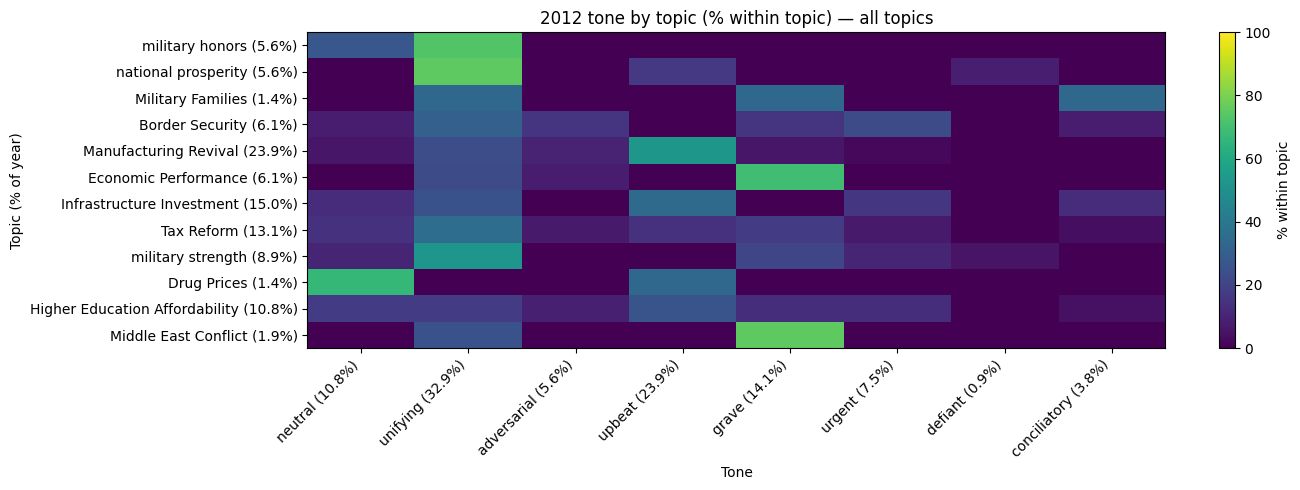

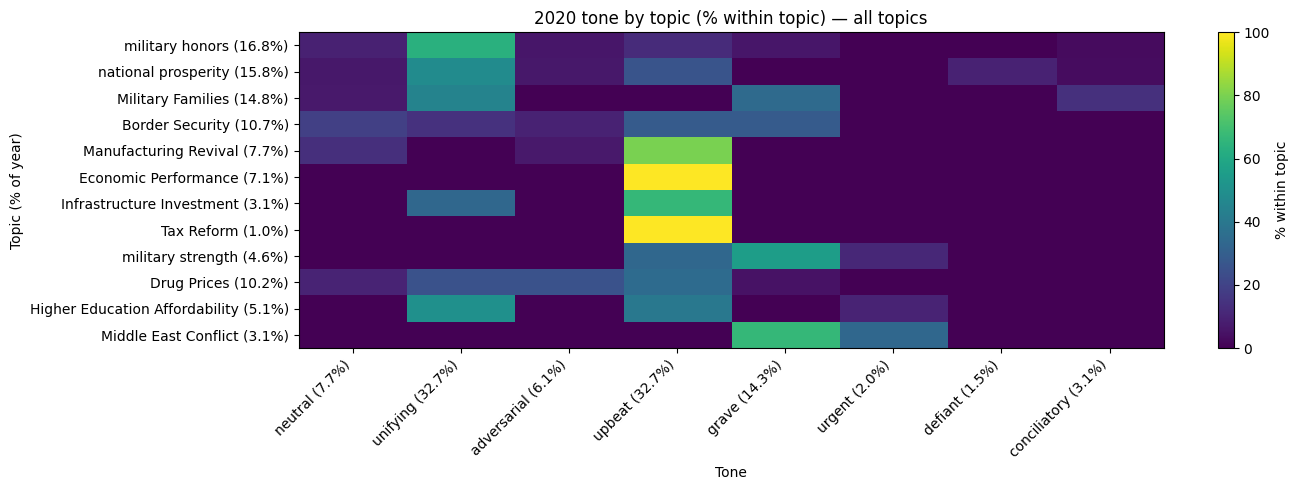

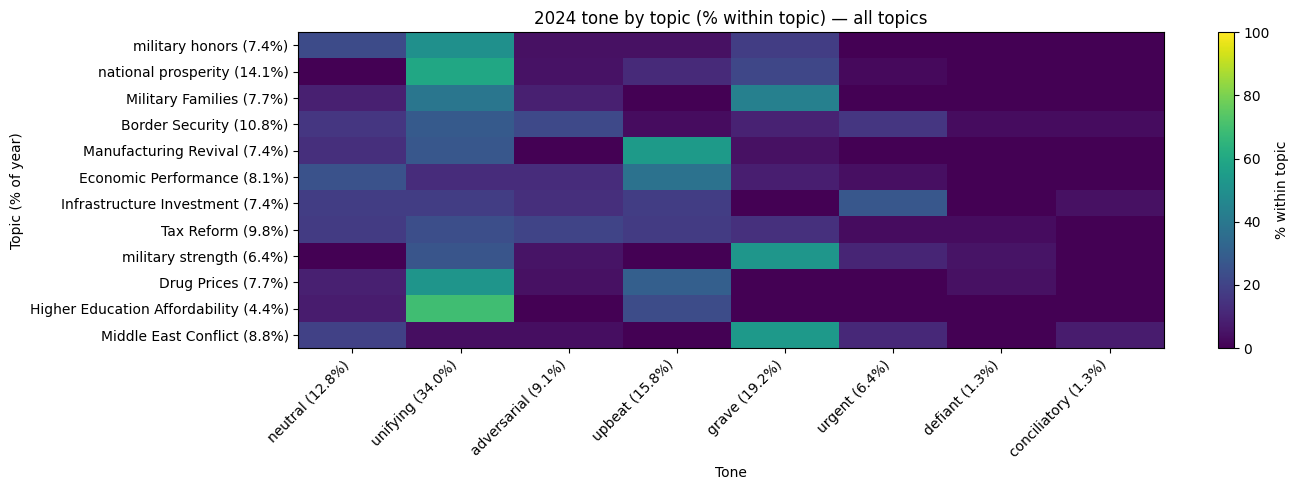

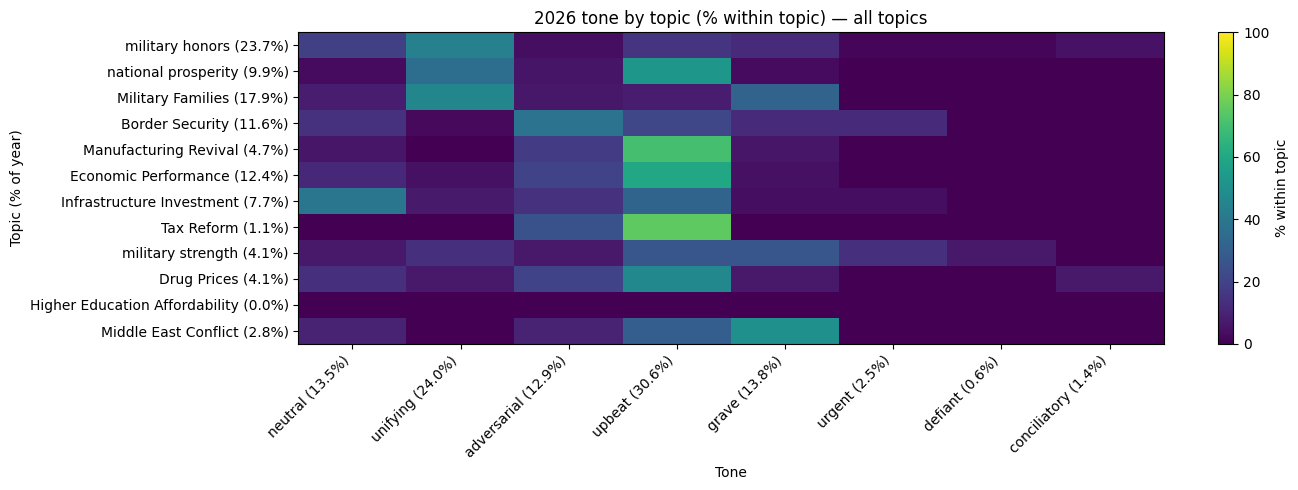

In [14]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

tones = ["neutral","unifying","adversarial","upbeat","grave","urgent","defiant","conciliatory"]

topic_order = (
    df2["topic_label"]
      .value_counts()
      .index
      .tolist()
)

def tone_heatmap_for_year_all_topics(data, year: int):
    sub = data[(data["year"] == year) & data["tone"].notna()].copy()

    # Tone distribution within topic
    counts = (
        sub.groupby(["topic_label","tone"])
           .size()
           .unstack(fill_value=0)
           .reindex(index=topic_order, columns=tones, fill_value=0)
    )
    totals = counts.sum(axis=1).replace(0, np.nan)
    pct = (counts.div(totals, axis=0) * 100.0).fillna(0.0)

    # Topic share within year (for y labels)
    topic_share = (sub["topic_label"].value_counts(normalize=True) * 100).reindex(topic_order).fillna(0.0)
    yticklabels = [f"{t} ({topic_share[t]:.1f}%)" for t in topic_order]

    tone_share = (sub["tone"].value_counts(normalize=True) * 100).reindex(tones).fillna(0.0)
    xticklabels = [f"{t} ({tone_share[t]:.1f}%)" for t in tones]

    fig, ax = plt.subplots(figsize=(14, max(5, 0.35 * len(topic_order))))
    im = ax.imshow(pct.values, aspect="auto", vmin=0, vmax=100)

    ax.set_title(f"{year} tone by topic (% within topic) — all topics")
    ax.set_xlabel("Tone")
    ax.set_ylabel("Topic (% of year)")
    ax.set_xticks(range(len(tones)))
#    ax.set_xticklabels(tones, rotation=45, ha="right")
    ax.set_xticklabels(xticklabels, rotation=45, ha="right")
    ax.set_yticks(range(len(topic_order)))
    ax.set_yticklabels(yticklabels)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("% within topic")

    plt.tight_layout()
    plt.show()

for y in sorted(df2["year"].unique()):
    tone_heatmap_for_year_all_topics(df2, y)


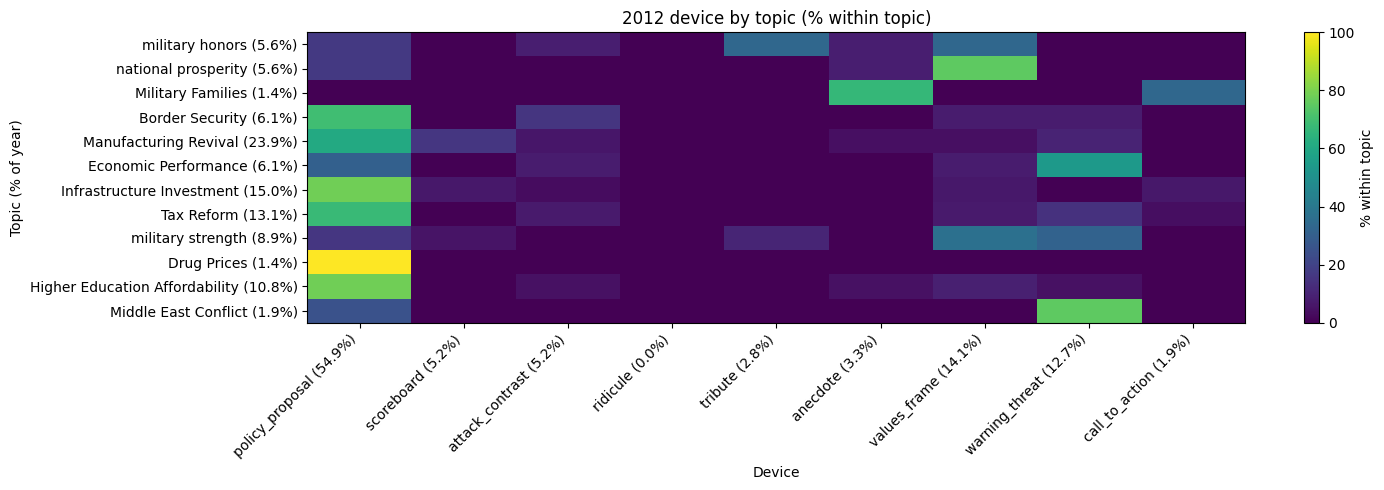

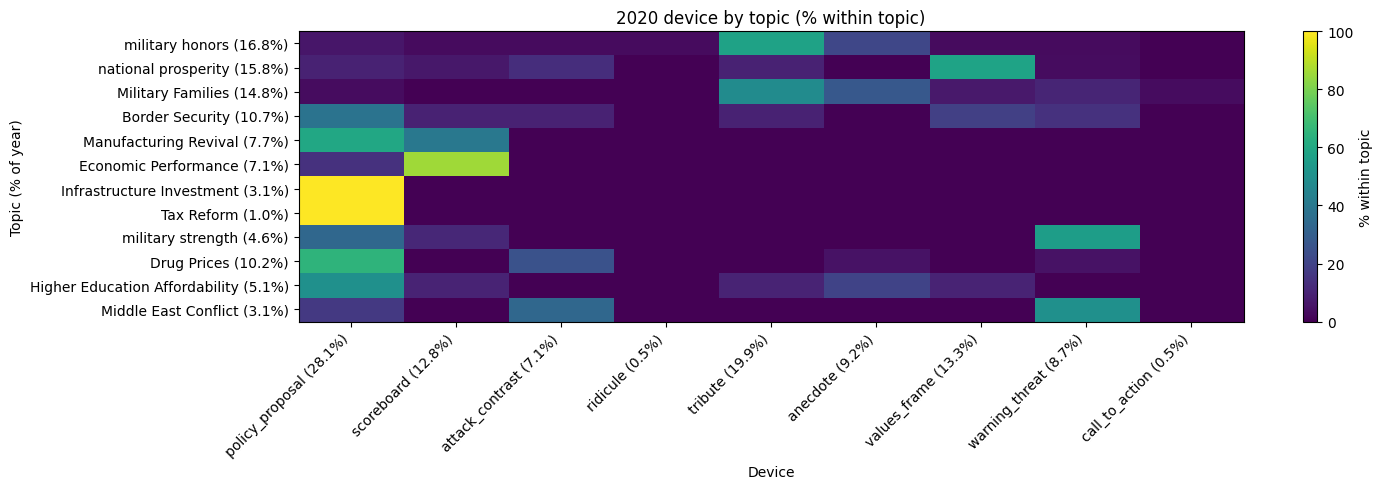

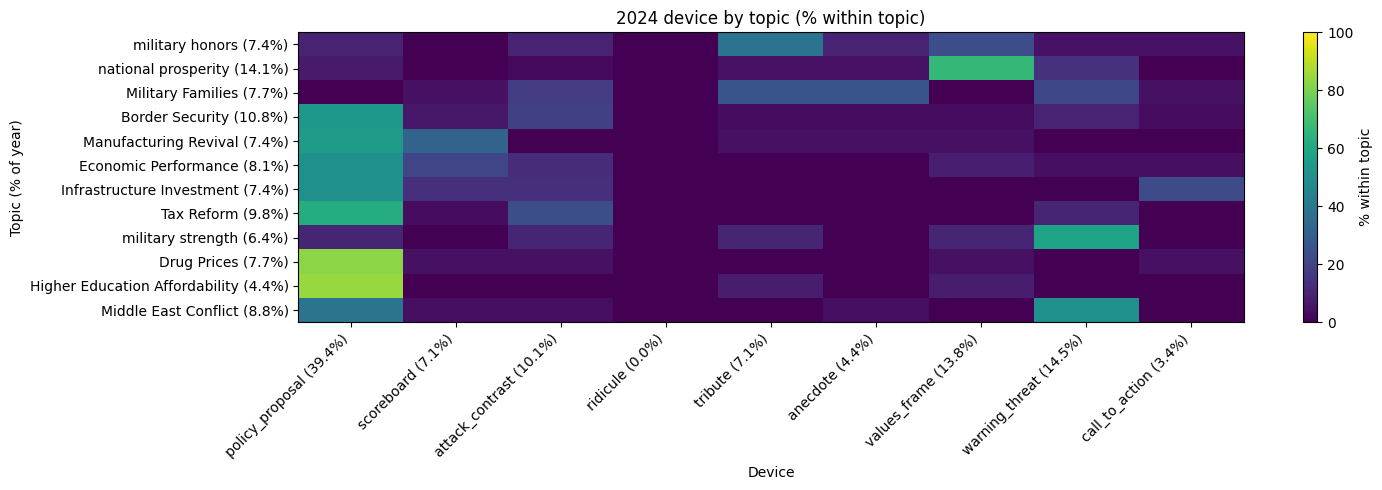

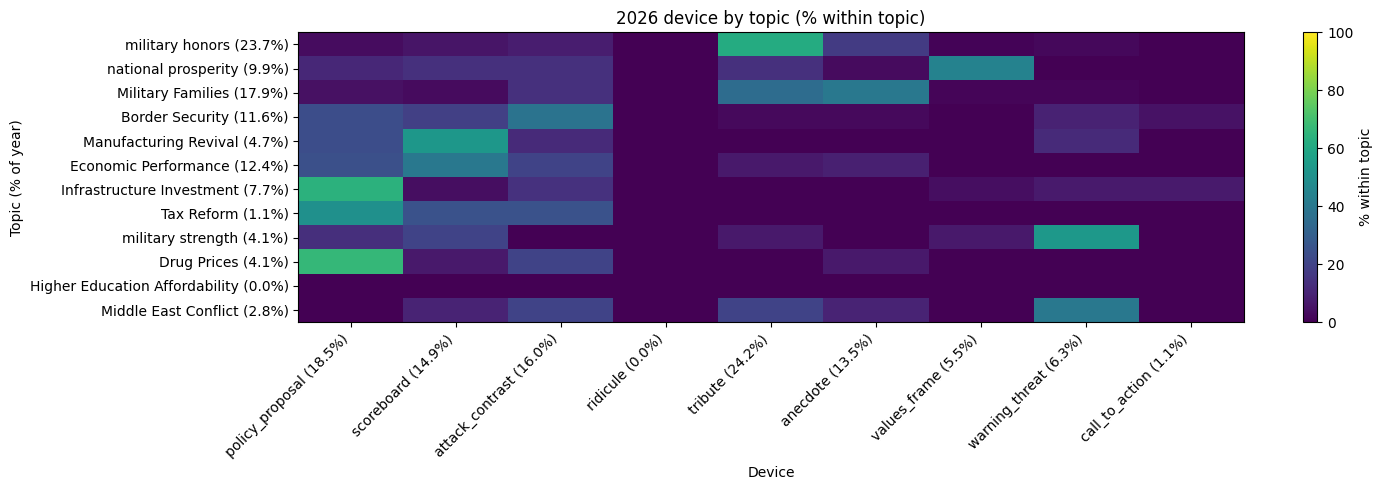

In [16]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

devices = [
    "policy_proposal","scoreboard","attack_contrast","ridicule",
    "tribute","anecdote","values_frame","warning_threat","call_to_action"
]

# fixed topic order for comparability
topic_order = df2["topic_label"].value_counts().index.tolist()

def device_topic_heatmap(data, year: int):
    sub = data[(data["year"] == year) & data["device"].notna()].copy()

    counts = (
        sub.groupby(["topic_label","device"])
           .size()
           .unstack(fill_value=0)
           .reindex(index=topic_order, columns=devices, fill_value=0)
    )

    totals = counts.sum(axis=1).replace(0, np.nan)
    pct = (counts.div(totals, axis=0) * 100.0).fillna(0.0)

    # y labels show topic share within the year (% of chunks in that year)
    topic_share = (sub["topic_label"].value_counts(normalize=True) * 100).reindex(topic_order).fillna(0.0)
    yticklabels = [f"{t} ({topic_share[t]:.1f}%)" for t in topic_order]

    device_share = (sub["device"].value_counts(normalize=True) * 100).reindex(devices).fillna(0.0)
    xticklabels = [f"{t} ({device_share[t]:.1f}%)" for t in devices]

    fig, ax = plt.subplots(figsize=(15, max(5, 0.35 * len(topic_order))))
    im = ax.imshow(pct.values, aspect="auto", vmin=0, vmax=100)

    ax.set_title(f"{year} device by topic (% within topic)")
    ax.set_xlabel("Device")
    ax.set_ylabel("Topic (% of year)")
    ax.set_xticks(range(len(devices)))
    ax.set_xticklabels(xticklabels, rotation=45, ha="right")
    ax.set_yticks(range(len(topic_order)))
    ax.set_yticklabels(yticklabels)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("% within topic")
    plt.tight_layout()
    plt.show()

for y in sorted(df2["year"].unique()):
    device_topic_heatmap(df2, y)



In [18]:

#sub = data[(data["year"] == year) & data["device"].notna()].copy()
df2.groupby(by="year")["device"].value_counts(normalize=True).unstack(fill_value=0).reindex(columns=devices, fill_value=0)

device,policy_proposal,scoreboard,attack_contrast,ridicule,tribute,anecdote,values_frame,warning_threat,call_to_action
year,,,,,,,,,
2012,0.549296,0.051643,0.051643,0.000000,0.028169,0.032864,0.140845,0.126761,0.018779
2020,0.280612,0.127551,0.071429,0.005102,0.198980,0.091837,0.132653,0.086735,0.005102
2024,0.393939,0.070707,0.101010,0.000000,0.070707,0.043771,0.138047,0.144781,0.033670
2026,0.184573,0.148760,0.159780,0.000000,0.242424,0.134986,0.055096,0.063361,0.011019


In [19]:
df2.groupby(by="year")["tone"].value_counts(normalize=True).unstack(fill_value=0).reindex(columns=tones, fill_value=0)

tone,neutral,unifying,adversarial,upbeat,grave,urgent,defiant,conciliatory
year,,,,,,,,
2012,0.107981,0.328638,0.056338,0.239437,0.140845,0.075117,0.009390,0.037559
2020,0.076531,0.326531,0.061224,0.326531,0.142857,0.020408,0.015306,0.030612
2024,0.127946,0.340067,0.090909,0.158249,0.191919,0.063973,0.013468,0.013468
2026,0.134986,0.239669,0.129477,0.305785,0.137741,0.024793,0.005510,0.013774


In [23]:
tone_merge = {
  "defiant": "adversarial",     # or "urgent" if you prefer, but adversarial is simpler
  "conciliatory": "unifying",
}
df2["tone_merged"] = df2["tone"].replace(tone_merge)

merged_tones = [t for t in tones if t not in ["defiant", "conciliatory"]]
df2.groupby(by="year")["tone_merged"].value_counts(normalize=True).unstack(fill_value=0).reindex(columns=merged_tones, fill_value=0)

tone_merged,neutral,unifying,adversarial,upbeat,grave,urgent
year,,,,,,
2012,0.107981,0.366197,0.065728,0.239437,0.140845,0.075117
2020,0.076531,0.357143,0.076531,0.326531,0.142857,0.020408
2024,0.127946,0.353535,0.104377,0.158249,0.191919,0.063973
2026,0.134986,0.253444,0.134986,0.305785,0.137741,0.024793


In [24]:
df2.topic_label.unique()

array(['military honors', 'military strength',
       'Higher Education Affordability', 'national prosperity',
       'Manufacturing Revival', 'Infrastructure Investment',
       'Economic Performance', 'Border Security', 'Middle East Conflict',
       'Tax Reform', 'Military Families', 'Drug Prices'], dtype=object)